# 随机森林
## 介绍
随机森林是一个集成学习方法，它通过构建多个决策树来进行分类或回归任务。每棵树都是在随机选择的特征子集上训练的，这样可以增加模型的多样性并减少过拟合的风险。随机森林在许多应用中表现出色，尤其是在处理高维数据和复杂关系时。
## 实现
  - 通过训练数据的不同子集，训练多个决策树来构建模型。每棵树都是独立训练的，使用不同的随机样本和特征子集。
  - 在预测阶段，通过对所有树的预测结果进行投票（分类）或平均（回归）来得出最终的预测结果。






In [1]:
 ## 生成数据集
 
from sklearn.datasets import make_moons #能生成两个半月交叠形状的数据集
from sklearn.model_selection import train_test_split #能将数据集划分为训练集和测试集

#* 生成数据集
#/ n_samples表示生成样本数量，noise添加噪声，random_state为随机种子保证每次生成的数据集相同
x, y = make_moons(n_samples=100, noise=0.25, random_state=3)

#* 划分数据集
#/ stratify=y表示按照y的类别比例进行划分（保证训练集、测试集中类别比例与原始数据相同
#/ 默认test_size=0.25表示划分25%的数据作为测试集
x_train, x_test, y_train, y_test = train_test_split(x, y, stratify=y, random_state=42)

In [2]:
 ## 训练随机森林模型
 
#/ ensemble模块是sklearn中集成学习算法的集合
from sklearn.ensemble import RandomForestClassifier

#* 训练模型
#/ n_estimators表示森林中树的数量（默认100）
forest = RandomForestClassifier(n_estimators=5, random_state=2)

#/ fit方法训练模型，传入训练数据和标签
#/ 自动并行训练，随机采样样本和特征构建每棵树，增加模型的多样性和鲁棒性
forest.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",5
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

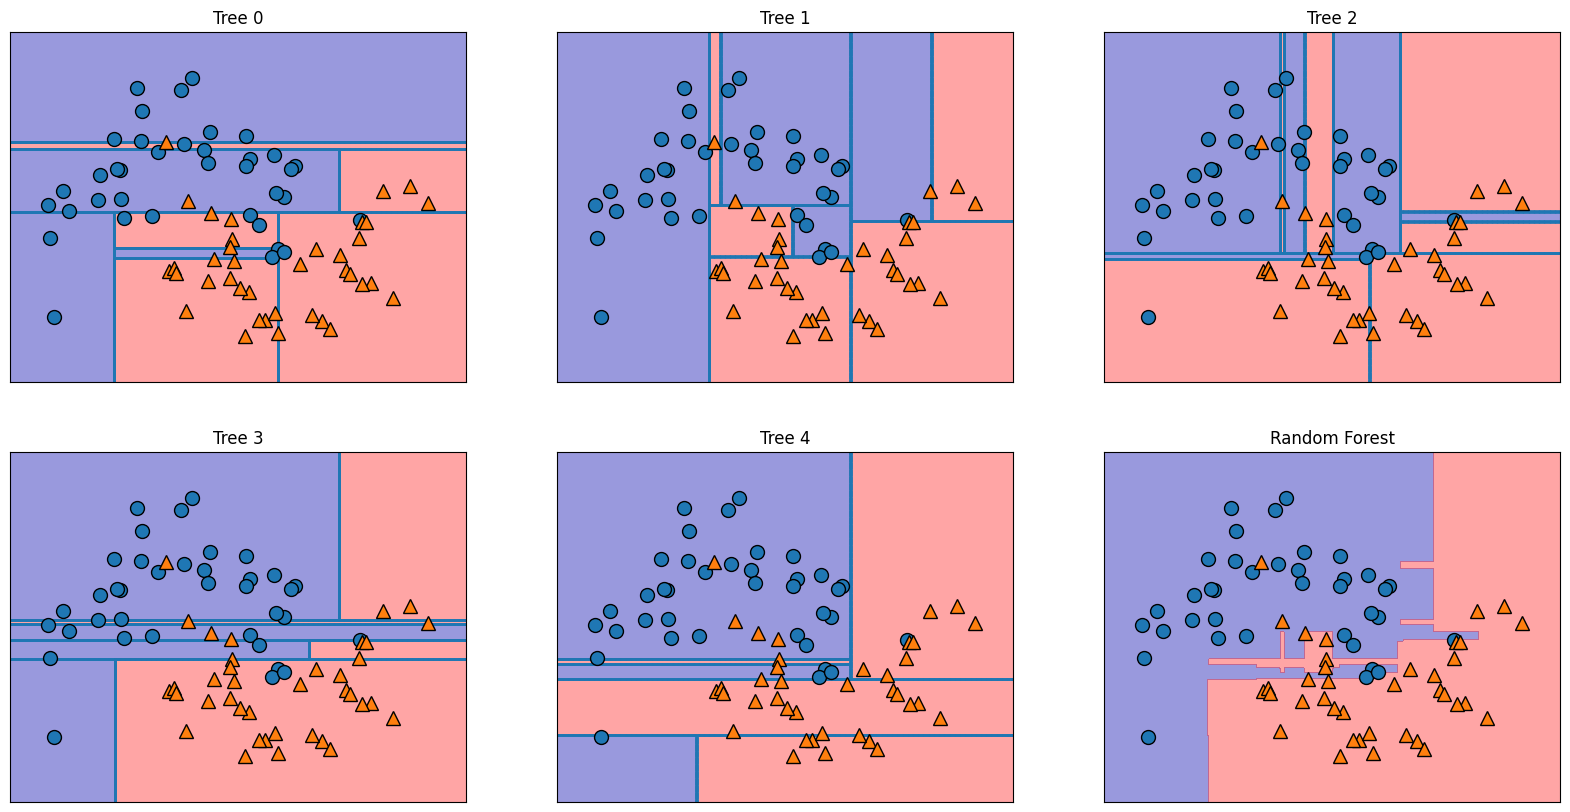

In [ ]:
 ## 可视化
 
import matplotlib.pyplot as plt
#/ mglearn库提供了许多可视化工具，特别适用于机器学习模型的展示
import mglearn

#* 创建子图（用于单独展示每个树）
#/ 2行3列，figsize表示图像大小
#/ 返回fig为图像对象，axes为子图对象的二维数组
fig, axes = plt.subplots(2, 3, figsize=(20, 10))

#* 遍历每个树和对应的子图
#/ ravel()将二维数组展平，estimators_属性包含森林中的每棵树
for i, (ax, tree) in enumerate(zip(axes.ravel(), forest.estimators_)):
    ax.set_title(f"Tree {i}")
    #/ 单棵树的边界和训练数据点
    mglearn.plots.plot_tree_partition(x_train, y_train, tree, ax)
    
#* 可视化随机森林的整体边界
#/ fill表示填充颜色，alpha表示透明度
mglearn.plots.plot_2d_separator(forest, x_train, fill=True, ax=axes[-1, -1], alpha=.4)
axes[-1, -1].set_title("Random Forest") #/ 等价于axes[1, 2]

#* 可视化训练数据点
mglearn.discrete_scatter(x_train[:, 0], x_train[:, 1], y_train)
plt.show()